# CIFAR-10 Data Visualization

This notebook visualizes training and test data from the CIFAR-10 dataset using PyTorch's built-in datasets module.

**CIFAR-10** contains 60,000 32x32 color images in 10 classes (6,000 images per class) with 50,000 training images and 10,000 test images.

## Classes
The 10 classes are:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

In [1]:
import sys
import os

# Adds the parent directory to python path
sys.path.append(os.path.abspath('..'))

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from data import cifar10

In [3]:
# Define CIFAR-10 class names
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
# Function to show images with ground truth labels
def imshow(img):
    """Display a single image and its label."""
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

def show_image_grid(images, labels, class_names):
    """
    Display a grid of images with their corresponding labels.
    
    Args:
        images: Tensor of shape (N, C, H, W)
        labels: List of label indices
        class_names: List of class name strings
    """
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i]
            label = labels[i] if isinstance(labels, list) else labels[i].item()
            ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
            ax.set_title(class_names[label])
            ax.axis('off')
        else:
            ax.axis('off')
    plt.tight_layout()
    plt.show()

In [5]:

# Show some sample images from training set
trainloader = cifar10.get_train_dataloader(batch_size=16)

C:\Users\megaa\miniconda3\envs\pt3.13\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


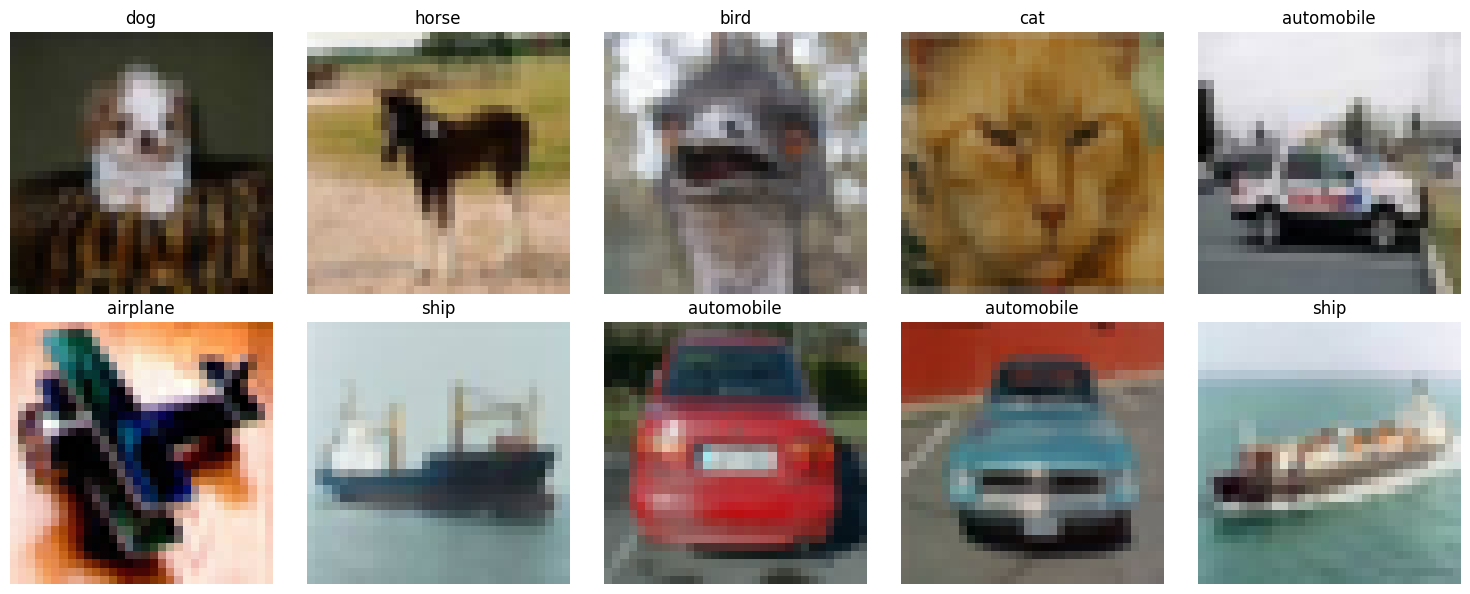

In [6]:
# Get some images from the training set
images, labels = next(iter(trainloader))

# Display training samples
show_image_grid(images, labels, CLASSES)

In [7]:
# Show some sample images from test set
testloader = cifar10.get_test_dataloader(batch_size=16)

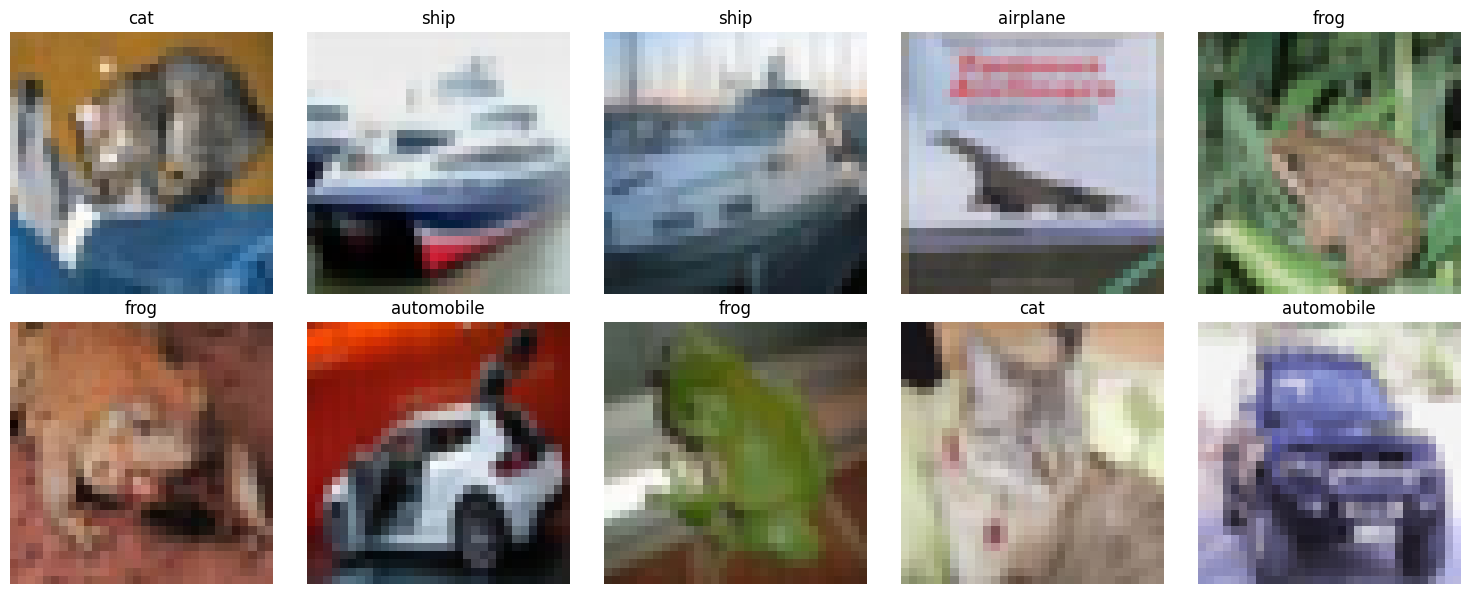

In [8]:
# Get some images from the test set
test_images, test_labels = next(iter(testloader))

# Display test samples
show_image_grid(test_images, test_labels, CLASSES)

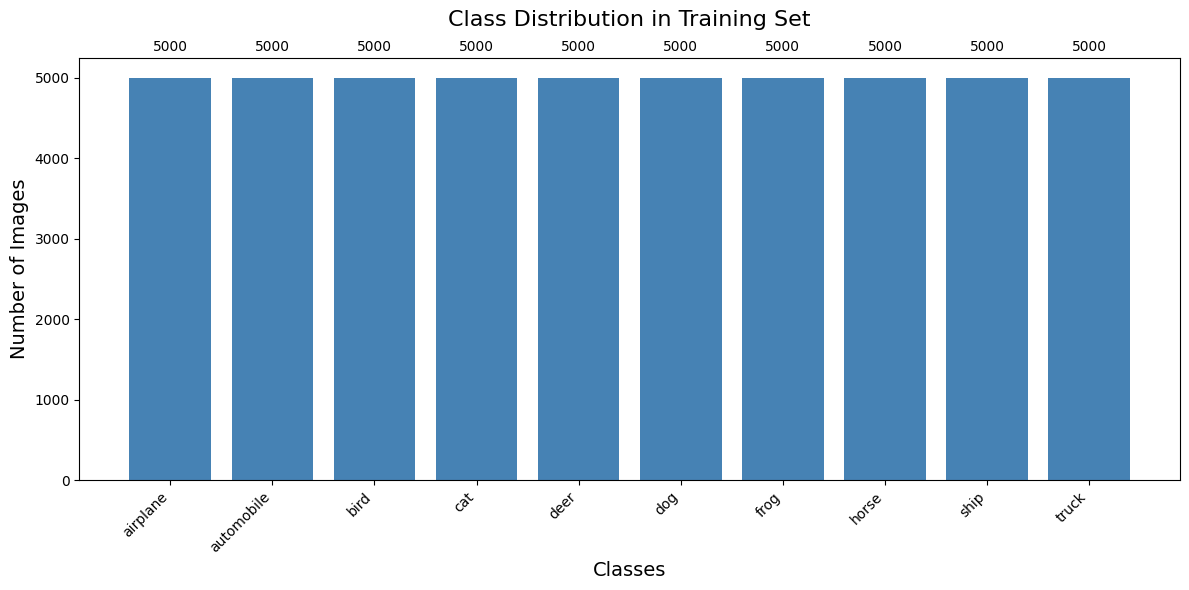

In [9]:
# Visualize class distribution in training set
train_labels = trainloader.dataset.targets
class_counts_train = np.bincount(train_labels, minlength=10)

plt.figure(figsize=(12, 6))
bars = plt.bar(CLASSES, class_counts_train, color='steelblue')
plt.title('Class Distribution in Training Set\n', fontsize=16)
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.xticks(range(10), CLASSES, rotation=45, ha='right')

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 300,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

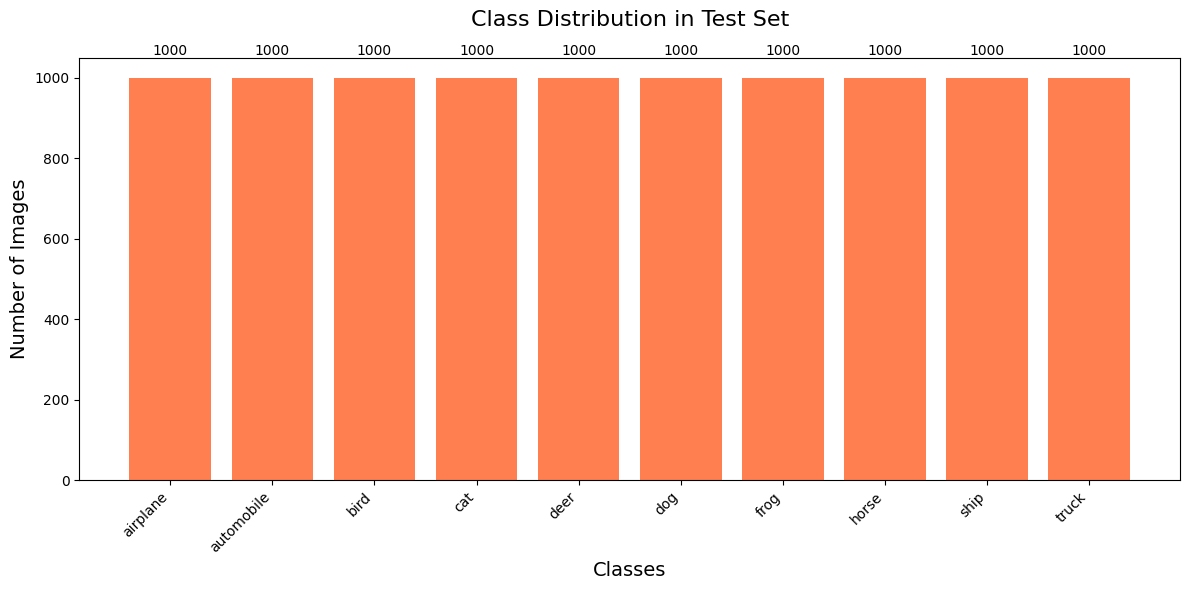

In [10]:
# Visualize class distribution in test set
test_labels = testloader.dataset.targets
class_counts_test = np.bincount(test_labels, minlength=10)

plt.figure(figsize=(12, 6))
bars = plt.bar(CLASSES, class_counts_test, color='coral')
plt.title('Class Distribution in Test Set\n', fontsize=16)
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.xticks(range(10), CLASSES, rotation=45, ha='right')

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

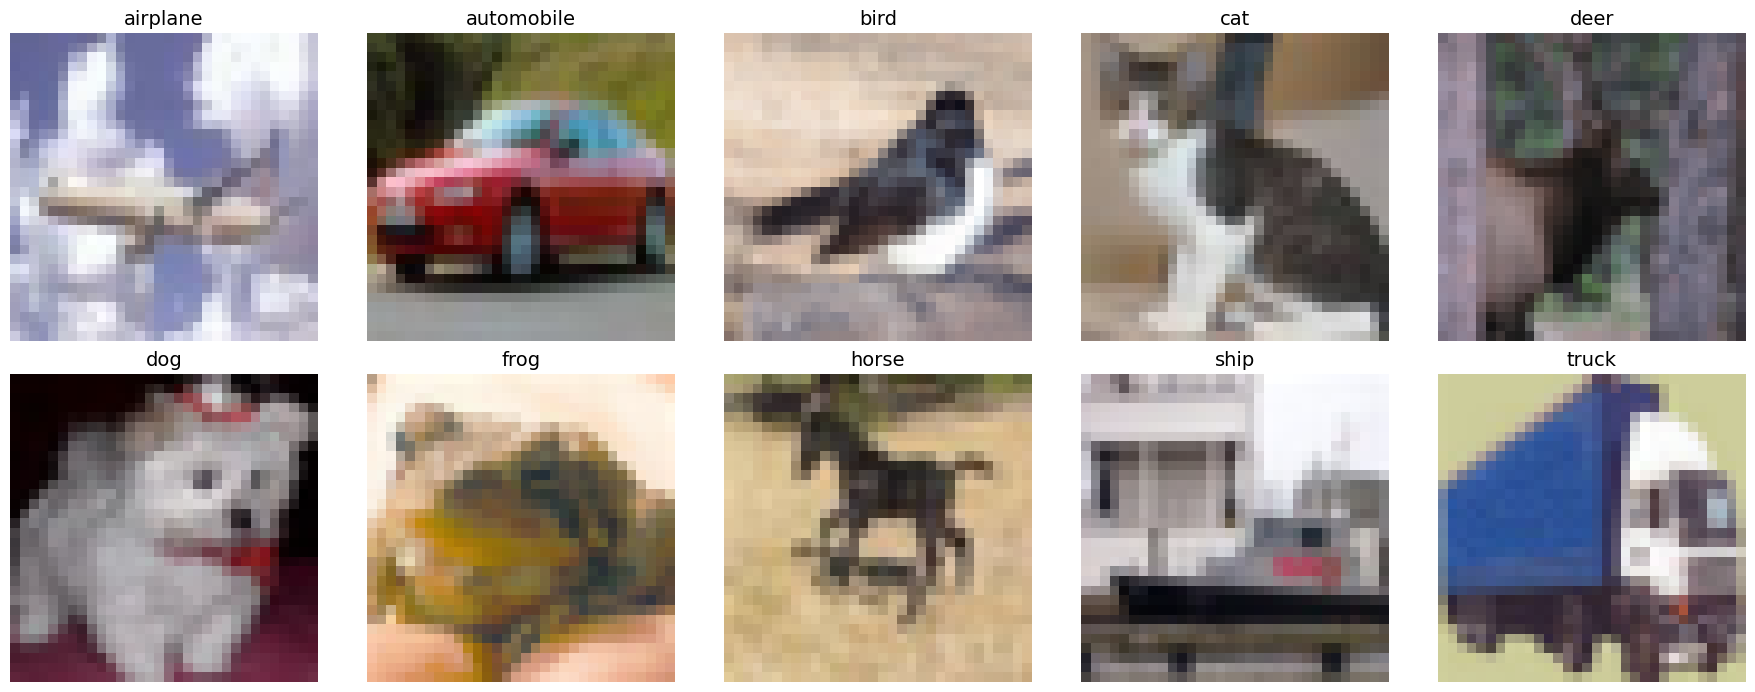

In [11]:
trainset = trainloader.dataset

# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, ax in enumerate(axes.flat):
    # Find an example of class i in training set
    indices = [j for j, label in enumerate(train_labels) if label == i]
    sample_idx = np.random.choice(indices)
    
    img, _ = trainset[sample_idx]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(CLASSES[i], fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Visualize image statistics
# Get all images from training set (sampling first 1000 for speed)
sample_size = min(1000, len(trainset))
indices = np.random.choice(len(trainset), sample_size, replace=False)

images = [trainset[i][0] for i in indices]
images_np = np.array([img.numpy().flatten() for img in images])

# Compute statistics
mean_per_channel = np.mean(images_np, axis=0).reshape(3, 32, 32)
std_per_channel = np.std(images_np, axis=0).reshape(3, 32, 32)